In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

from AnalysePoisson import *  
from AnalyseNegBinomial import *  

# Load data

In [2]:
Filename='Gentamicin'
#Filename='Ciprofloxacin'
#Filename='Chloramphenicol'
#Filename='Tetracycline'

singleCellData = pd.read_csv(f'Tables/{Filename}_measured.csv',index_col=0)
# ensure all droplets that were labelled as thrash are removed
singleCellData.drop(singleCellData[singleCellData['trash']].index, inplace = True)


dataset=0
singleCellData=singleCellData[singleCellData.dataset==dataset]# code considers only a single dataset because we set the threshold per dataset of 6 chips
removal_threshold=20 # this is the same threshold to define sucessful growth and needs to be adated according to the table in the ESI

In [3]:
singleCellData

,label,x,y,n_cells,n_cells_final,trash,dataset,date,date_index,concentration
0,1,899.004836,1464.147324,1,61,False,0,20221101,1,0.0
1,2,898.757073,2000.597171,1,64,False,0,20221101,1,0.0
2,3,899.213208,2532.335220,1,83,False,0,20221101,1,0.0
3,4,899.213208,3068.335220,0,0,False,0,20221101,1,0.0
4,5,899.402021,3607.967851,0,79,False,0,20221101,1,0.0
...,...,...,...,...,...,...,...,...,...,...
2994,495,6251.500000,18599.500000,2,0,False,0,20221101,1,2.0
2995,496,6251.500000,19139.309643,4,0,False,0,20221101,1,2.0
2996,497,6251.500000,19675.127017,4,2,False,0,20221101,1,2.0
2997,498,6251.500000,20211.309643,3,2,False,0,20221101,1,2.0


In [4]:
concentration = singleCellData.concentration.unique().tolist()

# Check if labeling missend any  outliers in number of initially detected cells: Makes computation more robust

<ol>
  <li> first automised overview of all concentrations and then look at the plots individually</li>
  <li> warning sometimes small counts cannot be seen by eye. So use extend of the x-axis to judge maximal count</li>
   <li> choose a removal threshold that works for all concentrations  </li>
  <li> c will be antibiotic concentration</li>
</ol> 

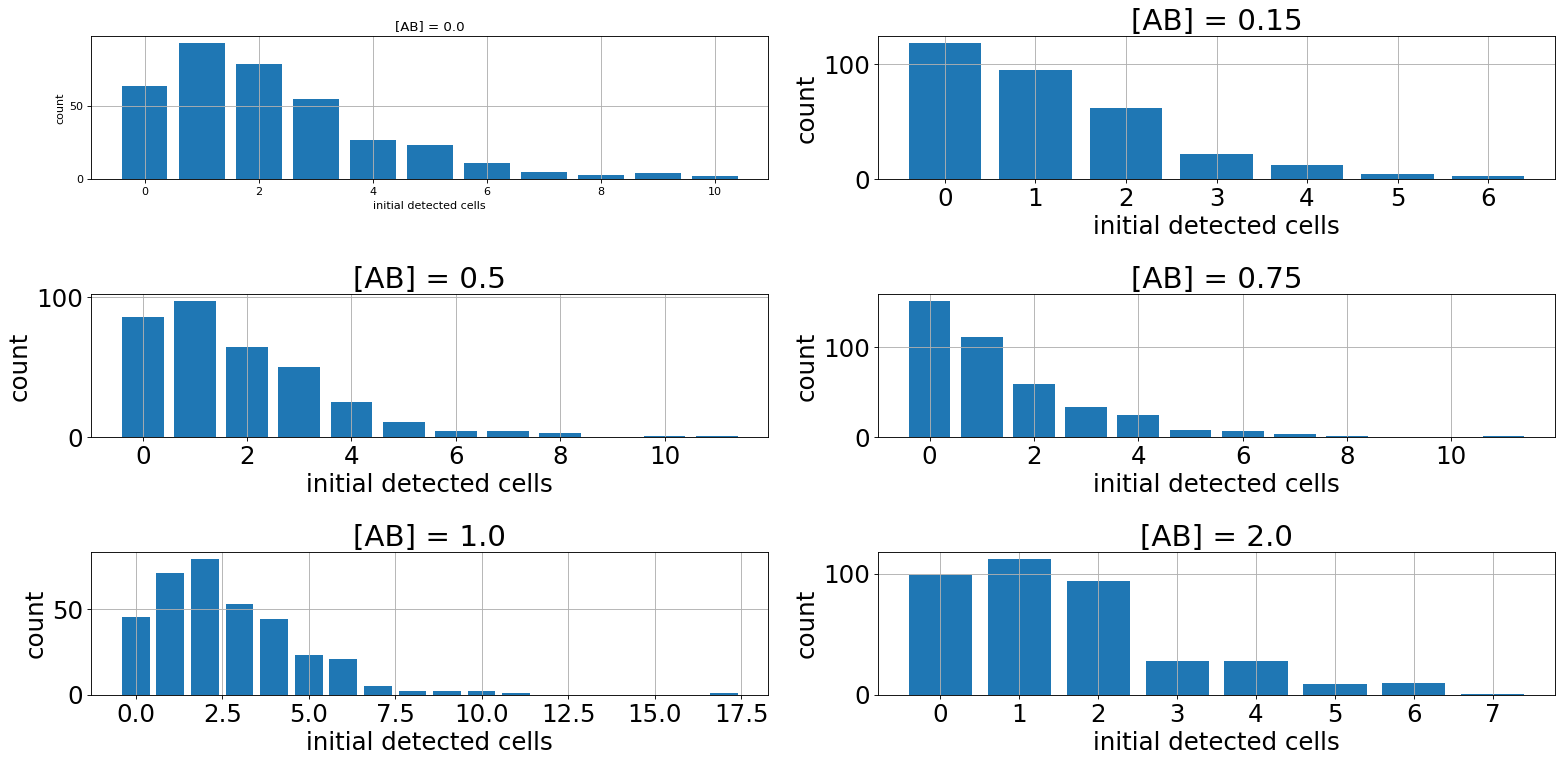

In [5]:
Tot = np.size(concentration)
Cols = 2
# Compute Rows required
Rows = Tot // Cols 
Rows += Tot % Cols

# Create a Position index
Position = range(1,Tot + 1)

fig = plt.figure(figsize=(20, 10), dpi=80)
for k in range(Tot):
  # add every single subplot to the figure with a for loop

    foo=singleCellData[singleCellData.concentration==concentration[k]].n_cells.reset_index()
    df=foo.groupby(['n_cells']).count()
    df=df.rename(columns={"index": "count"})
    initial_cells=np.sort(foo.n_cells.unique().tolist())

    ax = fig.add_subplot(Rows,Cols,Position[k])
    ax.bar(initial_cells,df['count'])
    plt.title(f'[AB] = {concentration[k]}')
    plt.xlabel('initial detected cells')
    plt.ylabel('count')
    plt.rcParams.update({'font.size': 22})
    plt.grid()
plt.tight_layout()
plt.show()

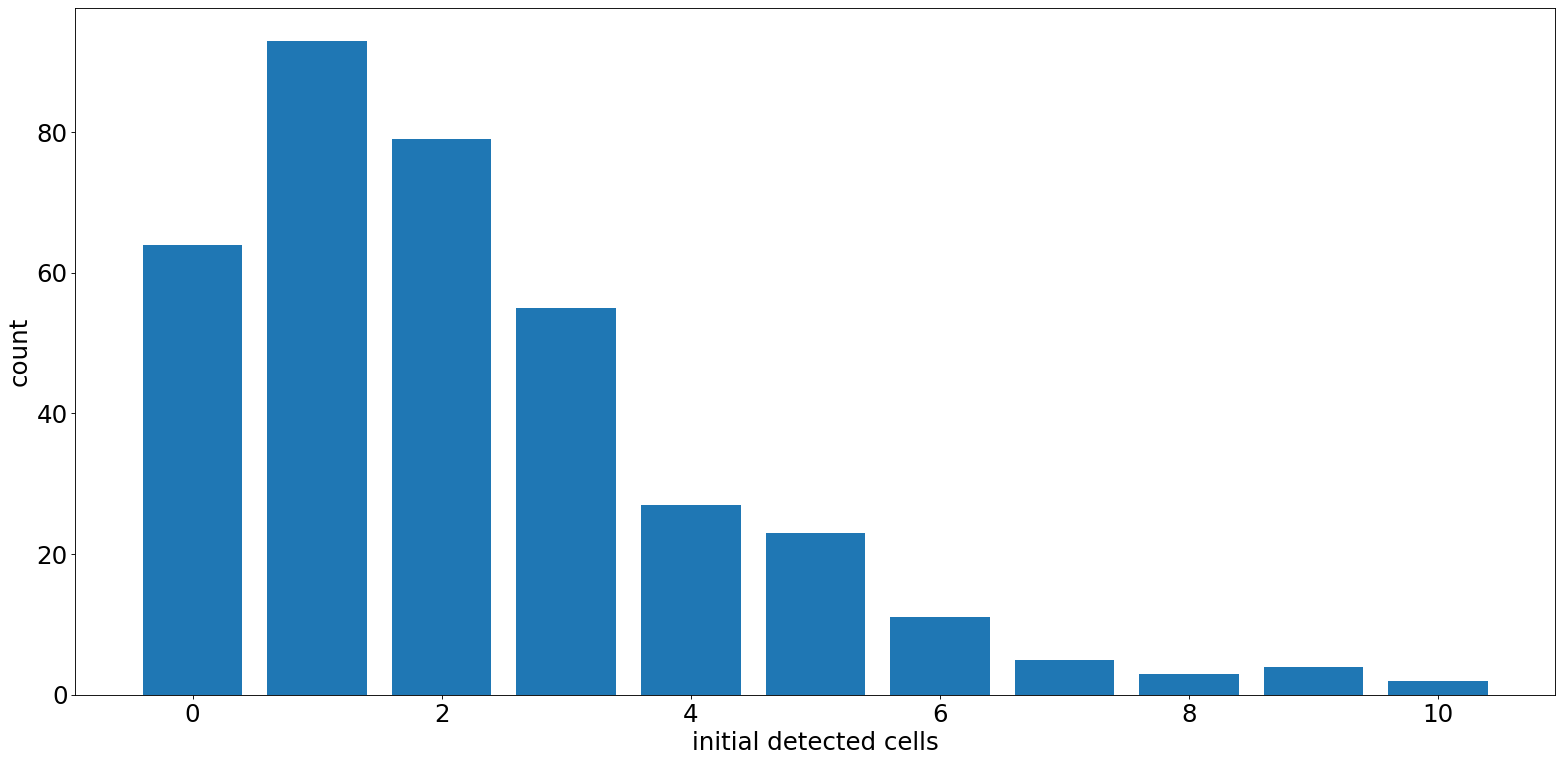

In [7]:
# look at a single panel:

c=0
foo=singleCellData[singleCellData.concentration==c].n_cells.reset_index()

df=foo.groupby(['n_cells']).count()
df=df.rename(columns={"index": "count"})

initial_cells=np.sort(foo.n_cells.unique().tolist())

plt.figure(figsize=(20, 10), dpi=80)
plt.bar(initial_cells,df['count'])
plt.rcParams.update({'font.size': 22})

plt.xlabel('initial detected cells')
plt.ylabel('count')
plt.tight_layout()

plt.show()

In [8]:
singleCellDataAjusted=singleCellData[singleCellData['n_cells']<removal_threshold]

## Print how many measurments have been removed

In [9]:
singleCellData.groupby(['concentration']).n_cells.count()-singleCellDataAjusted.groupby(['concentration']).n_cells.count()

concentration
0.00    0
0.15    0
0.50    0
0.75    0
1.00    0
2.00    0
Name: n_cells, dtype: int64

# Classify droplets as positive or negative

<ol>
  <li> intentionally non automised so one looks at the plots individually</li>
  <li> c will be antibiotic concentration</li>
</ol> 

<ol>
  <li> classify according to threshold of intensity or initial  cell number  </li>
  <li> classify according to Gaussian mixture </li>
  <li> compare classifications </li>
</ol>

## Look at dependence on the initial number of cells

/var/folders/w2/jt66jqzn6p7bsw4898xd2vn80000gn/T/ipykernel_61423/3251830351.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(ax=ax,data=singleCellDataAjusted[singleCellDataAjusted.concentration==concentration[k]], x="n_cells", y="n_cells_final",palette='bright')
/var/folders/w2/jt66jqzn6p7bsw4898xd2vn80000gn/T/ipykernel_61423/3251830351.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(ax=ax,data=singleCellDataAjusted[singleCellDataAjusted.concentration==concentration[k]], x="n_cells", y="n_cells_final",palette='bright')
/var/folders/w2/jt66jqzn6p7bsw4898xd2vn80000gn/T/ipykernel_61423/3251830351.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

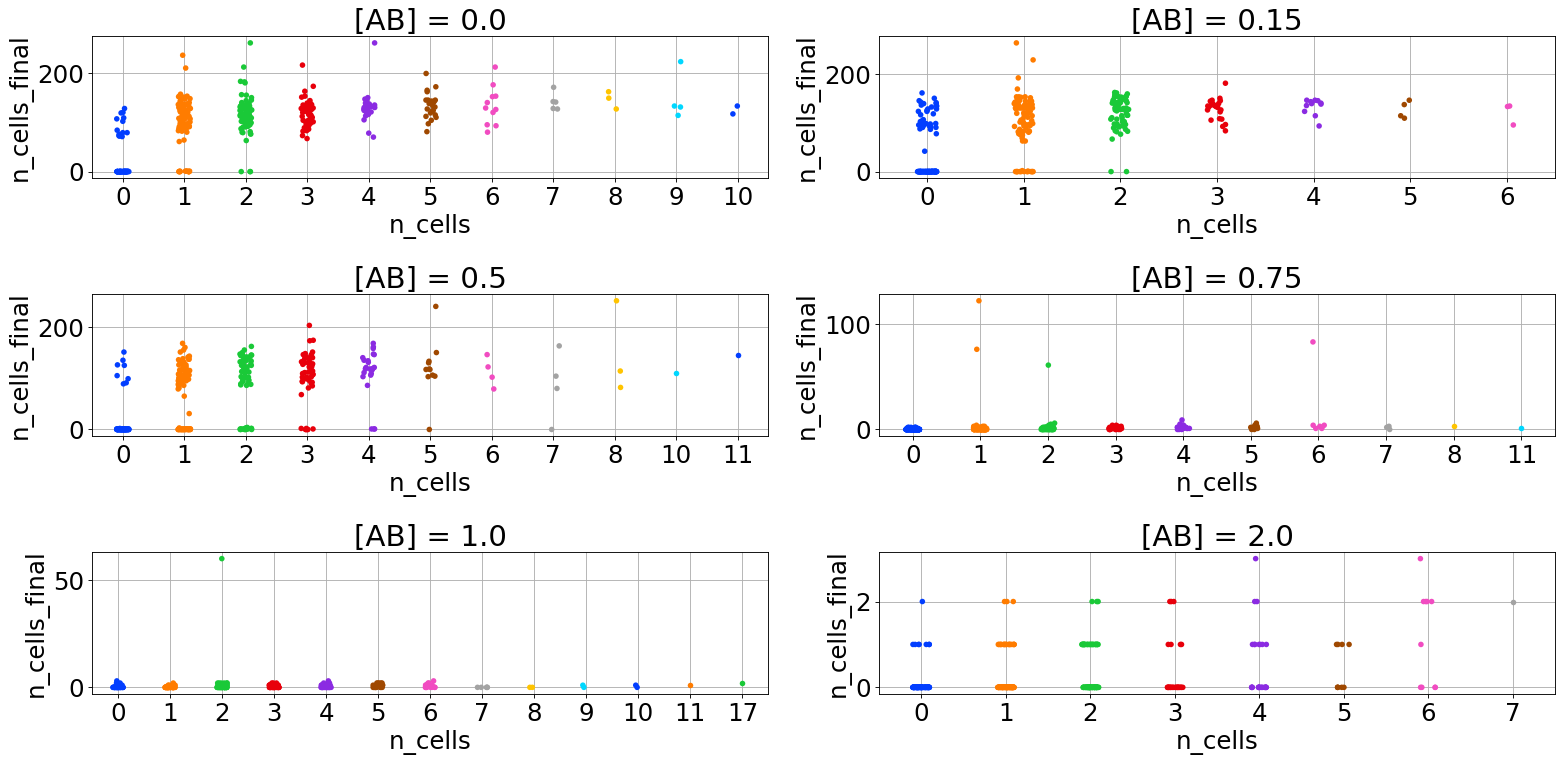

In [10]:
ylim=[-5,80]

Tot = np.size(concentration)
Cols = 2
# Compute Rows required
Rows = Tot // Cols 
Rows += Tot % Cols

# Create a Position index
Position = range(1,Tot + 1)

fig = plt.figure(figsize=(20, 10), dpi=80)
for k in range(Tot):
  # add every single subplot to the figure with a for loop
    ax = fig.add_subplot(Rows,Cols,Position[k])
    
    sns.stripplot(ax=ax,data=singleCellDataAjusted[singleCellDataAjusted.concentration==concentration[k]], x="n_cells", y="n_cells_final",palette='bright')

    plt.title(f'[AB] = {concentration[k]}')
    plt.grid()

    plt.rcParams.update({'font.size': 22})
plt.tight_layout()
plt.show()

# Show threshold classification

In [11]:
singleCellDataAjusted['dead']=singleCellDataAjusted.n_cells_final < removal_threshold
singleCellDataAjusted['dead'] =  singleCellDataAjusted.dead.replace({True: 1, False: 0})

# Analyse Chips

## Run Analysis

In [12]:
chip_info = (
    singleCellDataAjusted
    .groupby('concentration')
    .apply(lambda x: AnalyseNegBinomChip(x))
    .droplevel(level=1)
)
'''
chip_info = (
    singleCellDataAjusted
    .groupby('AB')
    .apply(lambda x: AnalysePoissonianChip(x))
    .droplevel(level=1)
)
'''

/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:301: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  foo=float(np.power(out['prob_neg_drop_zero_det']/out['prob_neg_drop'],1/out['r']))
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:303: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  if float(1+out['lambda_rho']/out['r'] ) > foo:
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:305: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  if foo > float(1+(out['lambda_rho']/out['r']) *(1-np.power(out['prob_neg_drop_zero_det'],1/out['r']))):
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBino

############################# Exit Analysis-###########################


/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:195: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  Cov[1,1]=1/Fisher_Info_r
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:301: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  foo=float(np.power(out['prob_neg_drop_zero_det']/out['prob_neg_drop'],1/out['r']))
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:303: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  if float(1+out['lambda_rho']/out['r'] ) > foo:
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:305: FutureWarning: Calling float on a single element Series is depreca

############################# Exit Analysis-###########################


/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:195: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  Cov[1,1]=1/Fisher_Info_r
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:301: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  foo=float(np.power(out['prob_neg_drop_zero_det']/out['prob_neg_drop'],1/out['r']))
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:303: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  if float(1+out['lambda_rho']/out['r'] ) > foo:
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:305: FutureWarning: Calling float on a single element Series is depreca

...

############################# Exit Analysis-###########################


/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:195: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  Cov[1,1]=1/Fisher_Info_r
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:301: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  foo=float(np.power(out['prob_neg_drop_zero_det']/out['prob_neg_drop'],1/out['r']))
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:303: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  if float(1+out['lambda_rho']/out['r'] ) > foo:
/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:305: FutureWarning: Calling float on a single element Series is depreca

############################# Exit Analysis-###########################
############################# Exit Analysis-###########################


/Users/erikmaikranz/Desktop/FiguresEndPoint/UploadToGithub/AnalyseNegBinomial.py:195: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  Cov[1,1]=1/Fisher_Info_r


"\nchip_info = (\n    singleCellDataAjusted\n    .groupby('AB')\n    .apply(lambda x: AnalysePoissonianChip(x))\n    .droplevel(level=1)\n)\n"

In [13]:
chip_info

,prob_neg_drop_one_det,prob_neg_drop_zero_det,prob_neg_drop,lambda_rho,var,r,q_single,q_chip,q_chip_uncor,rho,...,var_lam_chip_like,var_r_chip_like,var_rho_chip_like,var_q_chip_like,cov_lam_r_chip_like,cov_lam_rho_chip_like,cov_lam_q_chip_like,cov_r_rho_chip_like,cov_r_q_chip_like,cov_rho_q_chip_like
concentration,,,,,,,,,,,,,,,,,,,,,
0.00,0.139785,0.796875,0.183060,2.240437,3.920114,2.988408,0.189264,0.163781,0.000000,0.819458,...,3.991085e-02,0.398639,2.427097e-03,0.001654,3.756470e-02,-7.669204e-03,0.002983,-1.115570e-02,0.0,-0.000886
0.15,0.157895,0.703390,0.316456,1.174051,1.604531,3.201994,0.250549,0.253714,0.000000,0.632874,...,4.448740e-02,0.698542,4.560150e-03,0.002433,1.096083e-01,-1.210175e-02,0.004199,-3.770849e-02,0.0,-0.001445
0.50,0.381443,0.906977,0.424855,1.812139,3.173301,2.412531,0.437936,0.529253,0.432967,0.830192,...,4.791004e-02,0.346738,4.370355e-03,0.001439,3.838536e-02,-1.212730e-02,0.004705,-1.316922e-02,0.0,-0.001614
0.75,0.981982,1.000000,0.989950,1.371859,2.677493,1.441444,0.981982,0.992611,0.992611,1.000000,...,6.736783e-03,0.054969,1.876107e-35,0.000008,1.314908e-18,-1.174673e-19,0.000000,-9.584860e-19,0.0,0.000000
1.00,1.000000,1.000000,0.997135,2.641834,4.621348,3.525756,1.000000,0.998913,0.998913,1.000000,...,2.243585e+10,0.750058,4.701290e+00,0.000006,4.819105e+01,-3.247729e+05,351.443858,-6.975955e-04,0.0,-0.005087
2.00,1.000000,1.000000,1.000000,1.595801,2.241456,3.944177,1.000000,1.000000,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# add back meta data
metadata_cols = ['dataset', 'date', 'date_index']

metadata = (
    singleCellDataAjusted
    .groupby('concentration')[metadata_cols]
    .first()
)

chip_info = chip_info.join(metadata)
chip_info = chip_info.reset_index()

In [15]:
chip_info

,concentration,prob_neg_drop_one_det,prob_neg_drop_zero_det,prob_neg_drop,lambda_rho,var,r,q_single,q_chip,q_chip_uncor,...,var_q_chip_like,cov_lam_r_chip_like,cov_lam_rho_chip_like,cov_lam_q_chip_like,cov_r_rho_chip_like,cov_r_q_chip_like,cov_rho_q_chip_like,dataset,date,date_index
0,0.00,0.139785,0.796875,0.183060,2.240437,3.920114,2.988408,0.189264,0.163781,0.000000,...,0.001654,3.756470e-02,-7.669204e-03,0.002983,-1.115570e-02,0.0,-0.000886,0,20221101,1
1,0.15,0.157895,0.703390,0.316456,1.174051,1.604531,3.201994,0.250549,0.253714,0.000000,...,0.002433,1.096083e-01,-1.210175e-02,0.004199,-3.770849e-02,0.0,-0.001445,0,20221101,1
2,0.50,0.381443,0.906977,0.424855,1.812139,3.173301,2.412531,0.437936,0.529253,0.432967,...,0.001439,3.838536e-02,-1.212730e-02,0.004705,-1.316922e-02,0.0,-0.001614,0,20221101,1
3,0.75,0.981982,1.000000,0.989950,1.371859,2.677493,1.441444,0.981982,0.992611,0.992611,...,0.000008,1.314908e-18,-1.174673e-19,0.000000,-9.584860e-19,0.0,0.000000,0,20221101,1
4,1.00,1.000000,1.000000,0.997135,2.641834,4.621348,3.525756,1.000000,0.998913,0.998913,...,0.000006,4.819105e+01,-3.247729e+05,351.443858,-6.975955e-04,0.0,-0.005087,0,20221101,1
5,2.00,1.000000,1.000000,1.000000,1.595801,2.241456,3.944177,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,20221101,1


# Save Data

In [24]:
'''
this creastes the table for the single dataset but the github provided them unified for convenience
'''
chip_info.to_csv(f'{Folder}chip_info_{Filename}_NegBinom_{dataset}.csv')